In [14]:
# ================================
# 文件名: case3_risk_svm.py
# 主题: 金融风控客户初筛 - SVM 案例
# ================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (classification_report,
confusion_matrix,
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
RocCurveDisplay
)
def generate_risk_data(n_samples=3000, random_state=42):
    rng = np.random.default_rng(random_state)

    income_monthly = np.clip(rng.normal(12000, 5000, n_samples), 1500, 50000)
    debt_ratio = np.clip(rng.normal(0.42, 0.20, n_samples), 0, 1.2)
    credit_history_months = np.clip(rng.normal(36, 18, n_samples), 1, 180)
    overdue_count_12m = rng.poisson(0.8, n_samples)
    loan_inquiry_3m = rng.poisson(2.2, n_samples)
    job_stability_score = np.clip(rng.normal(65, 18, n_samples), 0, 100)
    device_change_count_6m = rng.poisson(1.0, n_samples)

    linear_score = (
        -0.00008 * income_monthly
        + 2.2 * debt_ratio
        - 0.018 * credit_history_months
        + 0.75 * overdue_count_12m
        + 0.35 * loan_inquiry_3m
        - 0.03 * job_stability_score
        + 0.30 * device_change_count_6m
        - 0.8
    )

    risk_prob = 1 / (1 + np.exp(-linear_score))
    risk = rng.binomial(1, risk_prob)

    return pd.DataFrame({
        "income_monthly": income_monthly,
        "debt_ratio": debt_ratio,
        "credit_history_months": credit_history_months,
        "overdue_count_12m": overdue_count_12m,
        "loan_inquiry_3m": loan_inquiry_3m,
        "job_stability_score": job_stability_score,
        "device_change_count_6m": device_change_count_6m,
        "risk": risk
    })

df = generate_risk_data()

X = df.drop(columns=["risk"])
y = df["risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=True, class_weight="balanced", random_state=42))
])

param_grid = {
    "svc__kernel": ["linear", "rbf"],
    "svc__C": [0.1, 1, 5, 10],
    "svc__gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("最佳参数:", grid.best_params_)
print("测试集 ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
最佳参数: {'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
测试集 ROC-AUC: 0.7840370018975331
              precision    recall  f1-score   support

           0       0.89      0.71      0.79       476
           1       0.38      0.67      0.48       124

    accuracy                           0.70       600
   macro avg       0.63      0.69      0.64       600
weighted avg       0.79      0.70      0.73       600



In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# ================================
# 二、全局绘图风格设置
# ================================
sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams["figure.figsize"] = (10, 6)
# ================================
def plot_decision_boundary(model, X, y, feature1, feature2, X_train=None, title="Decision Boundary", fixed_values=None):
    """
    绘制二维决策边界，支持高维特征。

    参数:
    - model: 训练好的模型，具有 predict 方法
    - X: 原始数据，用于确定特征范围（DataFrame 或 ndarray）
    - y: 标签，用于散点图着色
    - feature1: 第一个特征的名称（DataFrame）或索引（ndarray）
    - feature2: 第二个特征的名称（DataFrame）或索引（ndarray）
    - X_train: 训练数据，用于计算其他特征的均值（若为 None 则使用 X）
    - title: 图表标题
    - fixed_values: 其他特征的固定值（字典或数组），若提供则覆盖均值计算
    """
    # ---------- 处理 DataFrame ----------
    if isinstance(X, pd.DataFrame):
        all_features = X.columns.tolist()
        # 确定两个特征的范围
        x_min, x_max = X[feature1].min() - 1.0, X[feature1].max() + 1.0
        y_min, y_max = X[feature2].min() - 1.0, X[feature2].max() + 1.0

        # 创建网格
        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 400),
            np.linspace(y_min, y_max, 400)
        )

        # 确定其他特征的固定值
        if fixed_values is None:
            if X_train is None:
                X_train = X
            means = X_train.mean().to_dict()          # 计算各列均值
        else:
            means = fixed_values.copy()

        # 构建包含所有特征的网格 DataFrame
        grid_df = pd.DataFrame()
        grid_df[feature1] = xx.ravel()
        grid_df[feature2] = yy.ravel()
        for col in all_features:
            if col not in (feature1, feature2):
                if col in means:
                    grid_df[col] = means[col]
                else:
                    # 如果固定值中缺失该列，使用 0（可自行调整）
                    grid_df[col] = 0

        # 预测
        Z = model.predict(grid_df).reshape(xx.shape)

        # 绘图
        plt.figure(figsize=(8, 6))
        plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
        sns.scatterplot(x=X[feature1], y=X[feature2], hue=y, palette="Set1", edgecolor="k")
        plt.title(title)
        plt.xlabel(feature1)
        plt.ylabel(feature2)
        plt.tight_layout()
        plt.show()

    # ---------- 处理 ndarray ----------
    elif isinstance(X, np.ndarray):
        # 要求 feature1, feature2 为整数索引
        if not (isinstance(feature1, int) and isinstance(feature2, int)):
            raise ValueError("对于 numpy 数组，feature1 和 feature2 必须为整数索引")

        n_features = X.shape[1]
        idx1, idx2 = feature1, feature2

        # 确定两个特征的范围
        x_min, x_max = X[:, idx1].min() - 1.0, X[:, idx1].max() + 1.0
        y_min, y_max = X[:, idx2].min() - 1.0, X[:, idx2].max() + 1.0

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 400),
            np.linspace(y_min, y_max, 400)
        )

        # 确定其他特征的固定值
        if fixed_values is None:
            if X_train is None:
                X_train = X
            means = X_train.mean(axis=0)          # 各列均值，长度为 n_features
        else:
            if isinstance(fixed_values, dict):
                # 转换为数组，未指定的索引使用 0
                means = np.zeros(n_features)
                for k, v in fixed_values.items():
                    means[k] = v
            else:
                means = fixed_values

        # 构建网格（所有特征）
        grid = np.zeros((xx.ravel().shape[0], n_features))
        grid[:, idx1] = xx.ravel()
        grid[:, idx2] = yy.ravel()
        for j in range(n_features):
            if j not in (idx1, idx2):
                grid[:, j] = means[j]

        Z = model.predict(grid).reshape(xx.shape)

        plt.figure(figsize=(8, 6))
        plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
        sns.scatterplot(x=X[:, idx1], y=X[:, idx2], hue=y, palette="Set1", edgecolor="k")
        plt.title(title)
        plt.xlabel(f"Feature {idx1}")
        plt.ylabel(f"Feature {idx2}")
        plt.tight_layout()
        plt.show()

    else:
        raise TypeError("X 必须是 DataFrame 或 ndarray")

In [15]:
# =========================
# 练习3
# =========================

df = generate_risk_data()

X = df.drop(columns=["risk"])
y = df["risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=True, random_state=42))
])

param_grid = {
    "svc__kernel": ["linear", "rbf"],
    "svc__C": [0.1, 1, 5, 10],
    "svc__gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

acc=accuracy_score(y_test, y_pred)
prec=precision_score(y_test, y_pred)
recall=recall_score(y_test, y_pred)
f1=f1_score(y_test, y_pred)
auc=roc_auc_score(y_test, y_proba)
rec=recall_score(y_test, y_pred)

print("\n" + "=" * 80)
print("模型评估结果")
print("=" * 80)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 16 candidates, totalling 80 fits

模型评估结果
Accuracy : 0.7933
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000
ROC-AUC  : 0.7721
              precision    recall  f1-score   support

           0       0.79      1.00      0.88       476
           1       0.00      0.00      0.00       124

    accuracy                           0.79       600
   macro avg       0.40      0.50      0.44       600
weighted avg       0.63      0.79      0.70       600



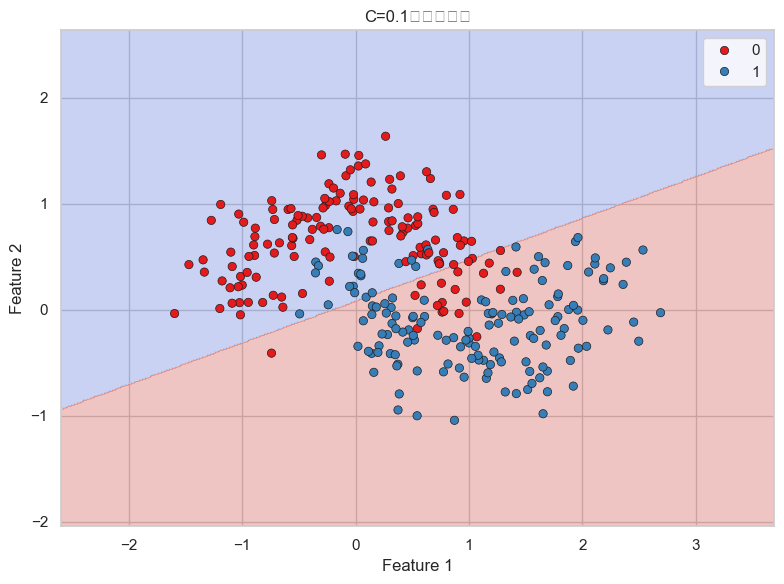

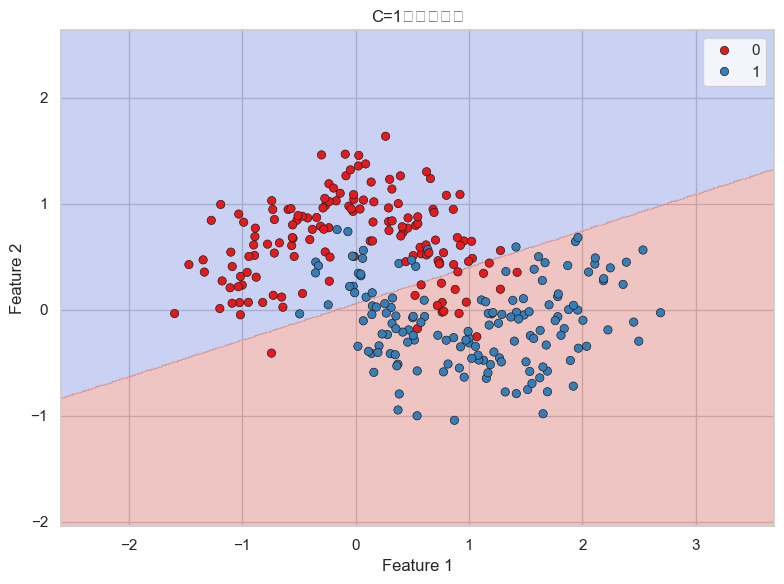

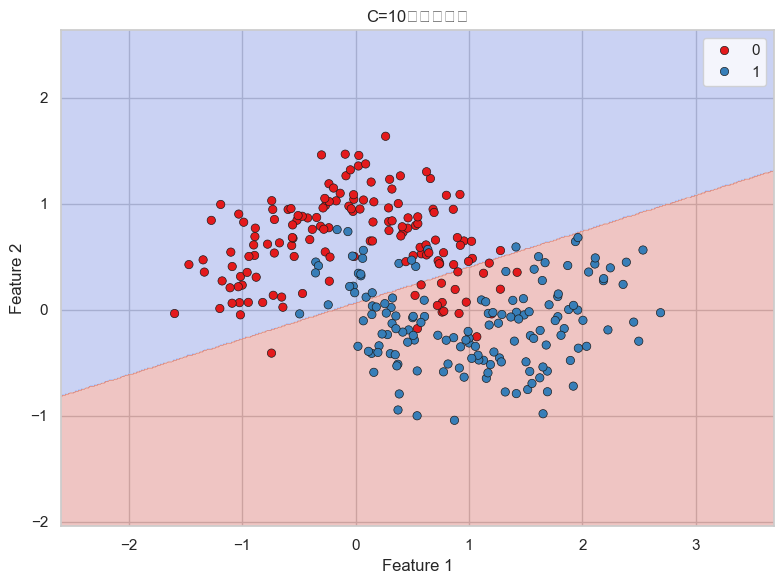

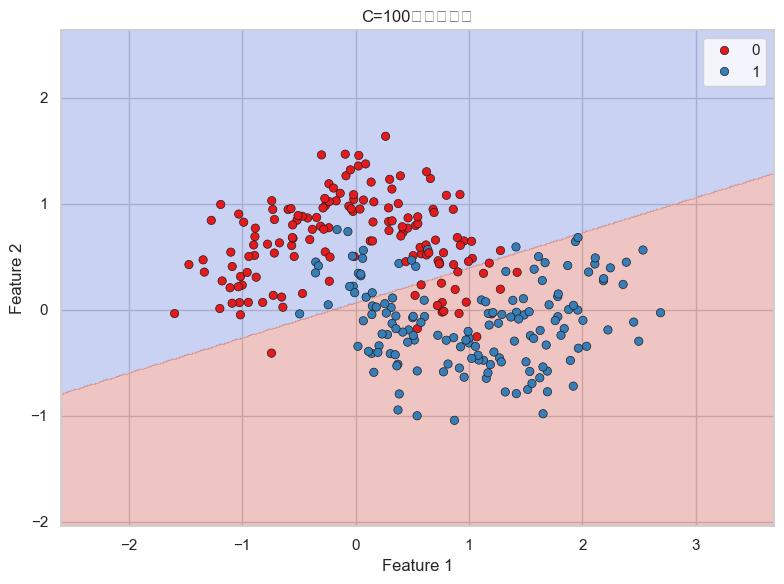

In [10]:
# ================================
# 文件名: svm_boundary_demo_phase2.py
# 主题: SVM 决策边界可视化
# 说明:
# 1. 用二维合成数据演示 SVM 边界
# 2. 对比不同 kernel / C / gamma 的效果
# ================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

sns.set_theme(style="whitegrid")

# 生成二维非线性数据
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

def plot_decision_boundary(model, X, y, title):
    """
    绘制二维决策边界
    """
    if isinstance(X, np.ndarray) :
        x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
        y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
    elif isinstance(X, pd.DataFrame) :
        x_min, x_max = X.iloc[:, 0].min() - 1.0, X.iloc[:, 0].max() + 1.0
        y_min, y_max = X.iloc[:, 1].min() - 1.0, X.iloc[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor="k")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()
    plt.show()

# =========================
# 练习1
# =========================

c_tests=[0.1,1,10,100]

for c in c_tests:
    svm_pipeline1 = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="linear",
            C=c,
            gamma="scale",
            probability=True,
            random_state=42,
            class_weight="balanced",
        ))
    ])
    svm_pipeline1.fit(X, y)
    plot_decision_boundary(svm_pipeline1, X, y ,title=f'C={c}的决策边界')
'''
SVM中参数C用于平衡训练样本正确分类与决策函数边际最大化，影响决策边界的确定。
软间隔允许一定程度的训练误差，支持向量可能来自同一类别的点。
C值大小决定了模型对分类精度与边界的权衡，
C增大时，决策边界收缩，模型更拟合数据，但可能过拟合；
C减小时，决策边界扩大，模型更简单，但可能牺牲训练准确性。
'''

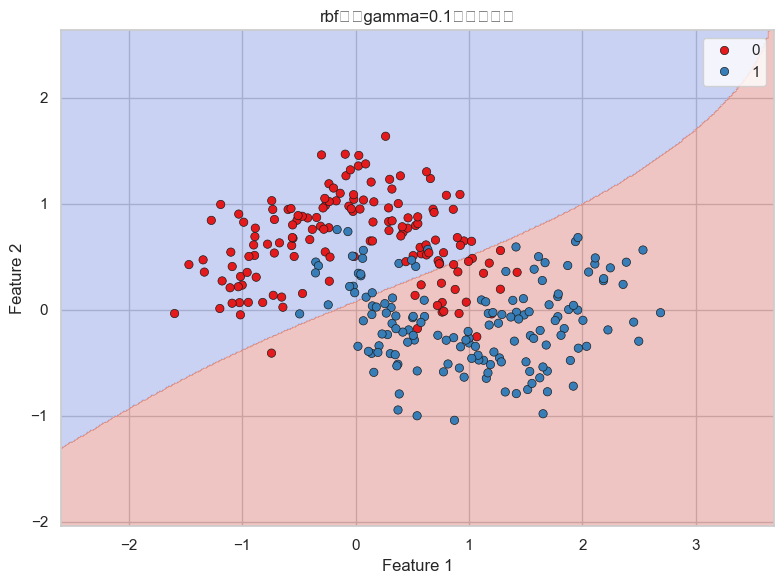

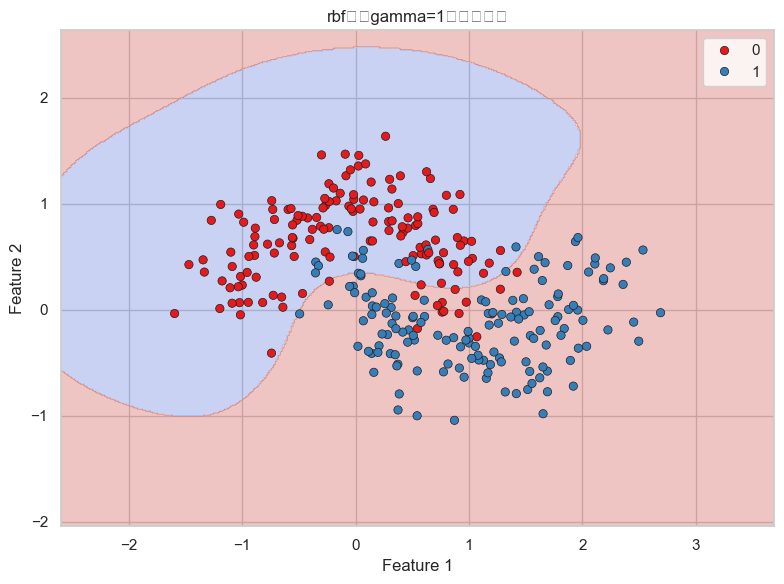

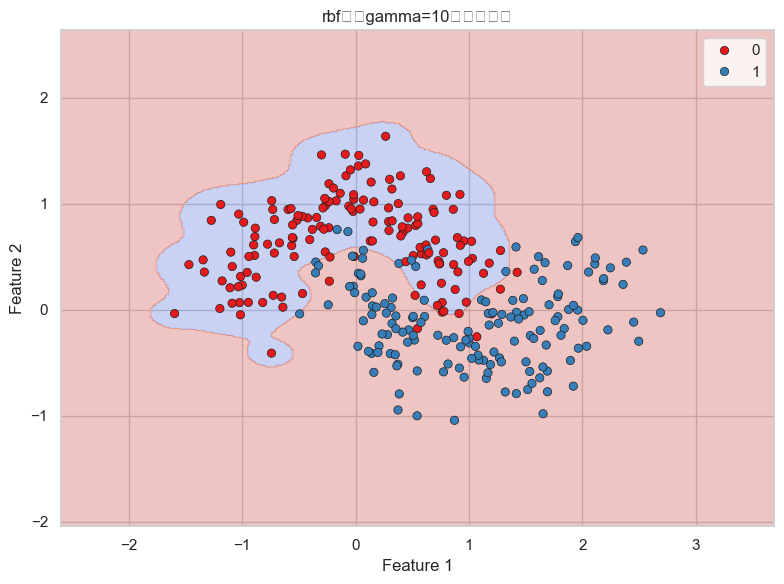

'\nGamma越大，样本点对决策边界的影响就越小，决策边界就越平滑；Gamma越小，样本点对决策边界的影响就越大，决策边界就越复杂\n'

In [12]:
# ================================
# 文件名: svm_boundary_demo_phase2.py
# 主题: SVM 决策边界可视化
# 说明:
# 1. 用二维合成数据演示 SVM 边界
# 2. 对比不同 kernel / C / gamma 的效果
# ================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

sns.set_theme(style="whitegrid")

# 生成二维非线性数据
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

def plot_decision_boundary(model, X, y, title):
    """
    绘制二维决策边界
    """
    if isinstance(X, np.ndarray) :
        x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
        y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
    elif isinstance(X, pd.DataFrame) :
        x_min, x_max = X.iloc[:, 0].min() - 1.0, X.iloc[:, 0].max() + 1.0
        y_min, y_max = X.iloc[:, 1].min() - 1.0, X.iloc[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor="k")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()
    plt.show()

# =========================
# 练习1
# =========================

nums=[0.1,1,10]

for n in nums:
    svm_pipeline1 = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=0.1,
            gamma=n,
            probability=True,
            random_state=42,
            class_weight="balanced",
        ))
    ])
    svm_pipeline1.fit(X, y)
    plot_decision_boundary(svm_pipeline1, X, y ,title=f'rbf下的gamma={n}的决策边界')
'''
当gamma非常大的时候，模型复杂度越高，模型过拟合（overfitting），模型对训练的数据集过于敏感，可以预见此时模型的返回能力肯定非常弱；
当gamma非常小的时候，模型复杂度越低，模型欠拟合（underfitting），模型不能够非常好的反映数据集；
'''

原始数据量: 300
加入异常点后数据量: 303
小 C = 0.1


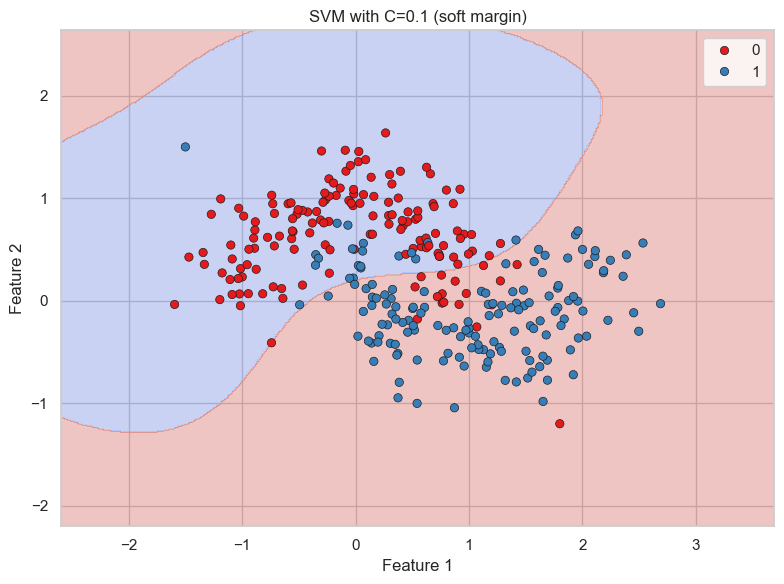

大 C = 100


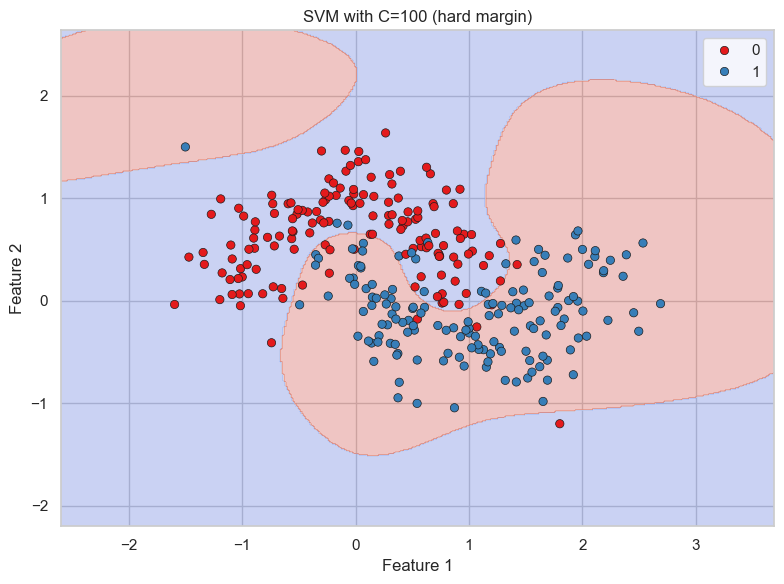

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 生成原始数据
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

# 手动添加异常点（例如：3个异常点，位置远离正常数据，标签设为 1 或 0）
outliers = np.array([
    [2.0, 0.5],   # 异常点1
    [1.8, -1.2],  # 异常点2
    [-1.5, 1.5]   # 异常点3
])
outlier_labels = np.array([1, 0, 1])  # 对应标签

# 将异常点添加到数据集中
X_with_outliers = np.vstack([X, outliers])
y_with_outliers = np.hstack([y, outlier_labels])

print(f"原始数据量: {X.shape[0]}")
print(f"加入异常点后数据量: {X_with_outliers.shape[0]}")

def train_svm(C_value, X, y, title):
    """训练 SVM 并绘制决策边界"""
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=C_value, gamma='auto', random_state=42))
    ])
    model.fit(X, y)

    # 调用已有的绘图函数
    plot_decision_boundary(model, X, y, title)
    return model

# 分别训练小 C 和大 C 的模型
print("小 C = 0.1")
svm_small_c = train_svm(0.1, X_with_outliers, y_with_outliers, "SVM with C=0.1 (soft margin)")

print("大 C = 100")
svm_large_c = train_svm(100, X_with_outliers, y_with_outliers, "SVM with C=100 (hard margin)")
'''
小 C（0.1）：决策边界比较平滑，不会为了适应少数异常点而大幅度扭曲。异常点可能被“忽略”或处于间隔内，整体泛化能力更强。

大 C（100）：决策边界会努力将所有训练点（包括异常点）正确分类，因此边界会变得非常曲折，
甚至出现孤立的小区域来包裹异常点。这可能导致过拟合，在测试集上表现可能变差。
'''